# UFC Pipeline — Scraping, ML & Classement

**Un seul notebook pour tout :** scraping incrémental, mise à jour des données, feature engineering, modèles ML et classement par division.

---
## Section 0 — Configuration

Modifiez les valeurs ci-dessous avant d'exécuter le notebook.

In [1]:
# ─── PARAMÈTRES MODIFIABLES ──────────────────────────────────────────────

# Poids pour le classement pondéré (doivent sommer à 1.0)
WEIGHTS = {
    'win_rate':        0.20,
    'finish_rate':     0.15,
    'sig_str_per_min': 0.15,
    'sig_str_acc':     0.10,
    'td_per_min':      0.10,
    'td_acc':          0.10,
    'ctrl_per_min':    0.10,
    'kd_per_min':      0.05,
    'sub_att_per_min': 0.05,
}

# Filtrer par division (None = toutes les divisions)
# Exemples : 'Lightweight', 'Heavyweight', 'Middleweight'
WEIGHT_CLASS_FILTER = None

# Nombre minimum de combats UFC pour apparaître dans le classement
MIN_FIGHTS_RANKING = 5

# ─── SETUP ────────────────────────────────────────────────────────────────
import sys, os
# Ajouter la racine du projet au path pour les imports
PROJECT_ROOT = os.path.abspath('')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)

STATE_FILE = os.path.join(PROJECT_ROOT, 'data', 'state', 'last_run.json')
MASTER_CSV = os.path.join(PROJECT_ROOT, 'data', 'processed', 'ufc_master_enriched.csv')

# Lire l'état du dernier run
with open(STATE_FILE, 'r') as f:
    state = json.load(f)

print('Configuration chargée')
print(f'Dernier run : {state["last_run"] or "jamais (premier run)"}')
print(f'Total combats connus : {state["n_fights_total"]}')
print(f'Filtre division : {WEIGHT_CLASS_FILTER or "toutes"}')
print(f'Min combats pour ranking : {MIN_FIGHTS_RANKING}')

Configuration chargée
Dernier run : jamais (premier run)
Total combats connus : 0
Filtre division : toutes
Min combats pour ranking : 5


---
## Section 1 — Mise à jour des données

1. Scraping incrémental ufcstats.com
2. Re-téléchargement des datasets Kaggle
3. Fusion et déduplication → master CSV
4. Mise à jour du state file

In [2]:
from datetime import date
from src.ingest.ingest_data import scrape_since
from src.processing.update_master import update

# Convertir last_run en date si non null
last_date = None
if state['last_run']:
    from datetime import datetime
    last_date = datetime.strptime(state['last_run'], '%Y-%m-%d').date()

print('=' * 60)
if last_date:
    print(f'Run INCREMENTAL — combats après le {last_date}')
else:
    print('PREMIER RUN — scraping de tous les combats')
print('=' * 60)

# 1. Scraping ufcstats
print('\n[1/2] Scraping ufcstats.com...')
df_scraped, n_scraped = scrape_since(last_date=last_date)
print(f'  Combats scrapés : {n_scraped}')

# 2. Mise à jour du master
print('\n[2/2] Mise à jour du master CSV...')
df_master, n_new = update(last_date=last_date)
print(f'  Nouveaux combats ajoutés : {n_new}')
print(f'  Total master : {len(df_master)} combats')

PREMIER RUN — scraping de tous les combats

[1/2] Scraping ufcstats.com...
Scraper UFC — mode complet (depuis : toujours)
  763 event(s) a scraper.
  [1/763] 0cfbbfa0ba6d9855 (None)
    +13 combats | Total : 13
  [2/763] 79ab17db3b40831a (None)
    +14 combats | Total : 27
  [3/763] c337c3c85b1871e0 (None)
    +13 combats | Total : 40
  [4/763] 30ad2050273d016a (None)
    +13 combats | Total : 53
  [5/763] 00e11b5c8b7bfeeb (None)
    +11 combats | Total : 64
  [6/763] bc0f994de0521926 (None)
    +12 combats | Total : 76
  [7/763] bd92cf5da5413d2a (None)
    +14 combats | Total : 90
  [8/763] 92c96df8bdab5fea (None)
    +14 combats | Total : 104
  [9/763] 8db1b36dde268ef6 (None)
    +14 combats | Total : 118
  [10/763] 6436029b50a9c255 (None)
    +12 combats | Total : 130
  [11/763] 0e2c2daf11b5d8f2 (None)
    +13 combats | Total : 143
  [12/763] 7956f026e2672c47 (None)
    +13 combats | Total : 156
  [13/763] 38e5d9dcb0fddc42 (None)
    +13 combats | Total : 169
  [14/763] 9336e86cfd4c

In [3]:
# Mise à jour du state file
today_str = date.today().isoformat()
state['last_run'] = today_str
state['n_fights_total'] = len(df_master)
os.makedirs(os.path.dirname(STATE_FILE), exist_ok=True)
with open(STATE_FILE, 'w') as f:
    json.dump(state, f, indent=2)

print(f'State mis a jour : last_run = {today_str}')
print(f'Total combats en base : {len(df_master)}')

State mis a jour : last_run = 2026-03-03
Total combats en base : 10369


---
## Section 2 — Aperçu du dataset

Structure du master CSV, statistiques globales, distributions.

In [4]:
df = pd.read_csv(MASTER_CSV)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values('date').reset_index(drop=True)

print(f'Shape : {df.shape}')
print(f'Periode : {df["date"].min().date()} -> {df["date"].max().date()}')
print(f'Nb fighters uniques : {pd.concat([df["R_Fighter"], df["B_Fighter"]]).nunique()}')
print(f'Taux victoire Rouge : {df["R_Win"].mean()*100:.1f}%')

# Colonnes disponibles
print(f'\nColonnes ({len(df.columns)}) :')
print(', '.join(df.columns.tolist()))

Shape : (10369, 115)
Periode : 1994-03-11 -> 2026-02-28
Nb fighters uniques : 2682
Taux victoire Rouge : 23.5%

Colonnes (115) :
R_Fighter, B_Fighter, R_KD, B_KD, R_SIG_STR_pct, B_SIG_STR_pct, R_TD_pct, B_TD_pct, R_SUB_ATT, B_SUB_ATT, R_REV, B_REV, method, last_round, last_round_time, Format, Referee, date, location, fight_type, Winner, R_SIG_STR_landed, R_SIG_STR_attempted, B_SIG_STR_landed, B_SIG_STR_attempted, R_TOTAL_STR_landed, R_TOTAL_STR_attempted, B_TOTAL_STR_landed, B_TOTAL_STR_attempted, R_TD_landed, R_TD_attempted, B_TD_landed, B_TD_attempted, R_HEAD_landed, R_HEAD_attempted, B_HEAD_landed, B_HEAD_attempted, R_BODY_landed, R_BODY_attempted, B_BODY_landed, B_BODY_attempted, R_LEG_landed, R_LEG_attempted, B_LEG_landed, B_LEG_attempted, R_DISTANCE_landed, R_DISTANCE_attempted, B_DISTANCE_landed, B_DISTANCE_attempted, R_CLINCH_landed, R_CLINCH_attempted, B_CLINCH_landed, B_CLINCH_attempted, R_GROUND_landed, R_GROUND_attempted, B_GROUND_landed, B_GROUND_attempted, R_CTRL_sec, B_C

In [5]:
# Aperçu des 5 combats les plus récents
display_cols = [c for c in ['date','R_Fighter','B_Fighter','WeightClass',
                             'method','last_round','R_Win'] if c in df.columns]
print('5 combats les plus récents :')
df[display_cols].tail(5)

5 combats les plus récents :


,date,R_Fighter,B_Fighter,WeightClass,method,last_round,R_Win
10364,NaT,Warlley Alves,Jeremiah Wells,NaN,NaN,NaN,0
10365,NaT,Charles Rosa,Justin Jaynes,NaN,NaN,NaN,1
10366,NaT,Julia Avila,Julija Stoliarenko,NaN,NaN,NaN,1
10367,NaT,Tim Means,Nicolas Dalby,NaN,NaN,NaN,1
10368,NaT,Raoni Barcelos,Timur Valiev,NaN,NaN,NaN,0


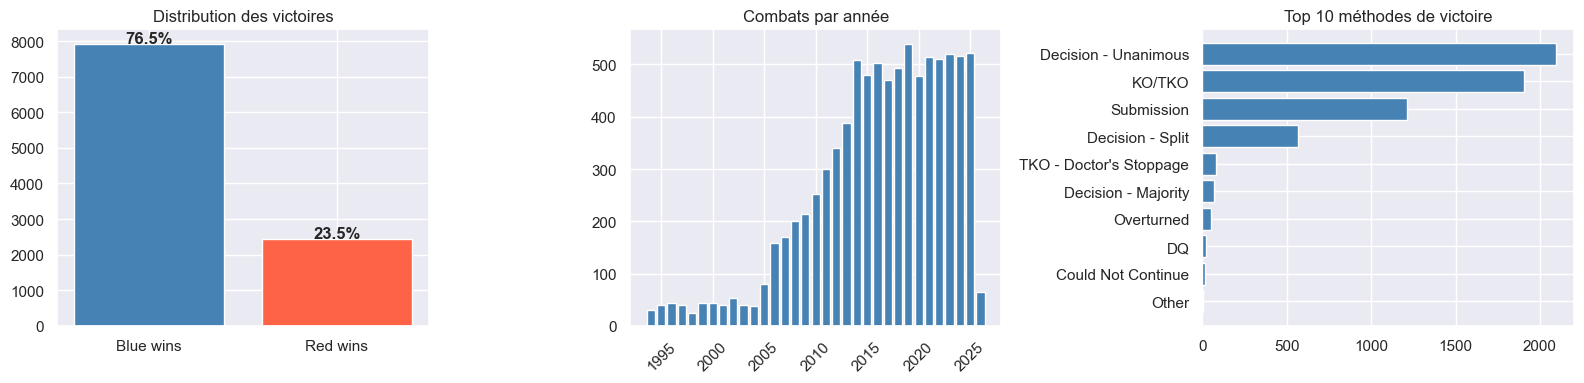

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution victoires
win_counts = df['R_Win'].value_counts()
axes[0].bar(['Blue wins', 'Red wins'],
            [win_counts.get(0, 0), win_counts.get(1, 0)],
            color=['steelblue', 'tomato'])
axes[0].set_title('Distribution des victoires')
for i, v in enumerate([win_counts.get(0, 0), win_counts.get(1, 0)]):
    axes[0].text(i, v + 20, f'{v/len(df)*100:.1f}%', ha='center', fontweight='bold')

# Combats par année
df['year'] = df['date'].dt.year
yearly = df.groupby('year').size()
axes[1].bar(yearly.index, yearly.values, color='steelblue', edgecolor='white')
axes[1].set_title('Combats par année')
axes[1].tick_params(axis='x', rotation=45)

# Méthodes de victoire
if 'method' in df.columns:
    methods = df['method'].value_counts().head(10)
    axes[2].barh(methods.index[::-1], methods.values[::-1], color='steelblue')
    axes[2].set_title('Top 10 méthodes de victoire')

plt.tight_layout()
plt.show()

---
## Section 3 — Feature Engineering

Vectorisation sans data leakage via `expanding().mean().shift(1)` par fighter.

Pour un combat à la date T, chaque feature = statistique cumulée des combats **avant T**.

In [7]:
from src.processing.feature_engineering import build_features, get_feature_cols

print('Construction des features (peut prendre 30-60 secondes)...')
features_df = build_features(df)

feat_cols = get_feature_cols(features_df, include_odds=True)
feat_cols_no_odds = get_feature_cols(features_df, include_odds=False)

print(f'Shape features : {features_df.shape}')
print(f'Nb features (avec cotes) : {len(feat_cols)}')
print(f'Nb features (sans cotes) : {len(feat_cols_no_odds)}')
print(f'Cible R_Win : {features_df["R_Win"].mean()*100:.1f}% Rouge')

Construction des features (peut prendre 30-60 secondes)...
Shape features : (45517, 47)
Nb features (avec cotes) : 40
Nb features (sans cotes) : 38
Cible R_Win : 50.1% Rouge


In [8]:
# Valeurs manquantes par feature
null_pct = features_df[feat_cols].isnull().mean() * 100
null_pct = null_pct.sort_values(ascending=False)

print('Valeurs manquantes par feature :')
for col, pct in null_pct.items():
    if pct > 0:
        print(f'  {col:45s}  {pct:.1f}%')
print(f'\n{(null_pct == 0).sum()} features sans valeurs manquantes')

Valeurs manquantes par feature :
  delta_implied_prob                             97.0%
  R_implied_prob                                 97.0%
  delta_age                                      90.3%
  B_age                                          90.3%
  R_age                                          90.0%
  delta_recent3_KD_pm                            57.1%
  delta_recent3_SIG_STR_landed_pm                57.0%
  delta_reach                                    50.4%
  delta_height                                   44.6%
  delta_avg_CTRL_sec_pm                          0.5%
  delta_avg_SUB_ATT_pm                           0.0%
  delta_avg_KD_pm                                0.0%

28 features sans valeurs manquantes


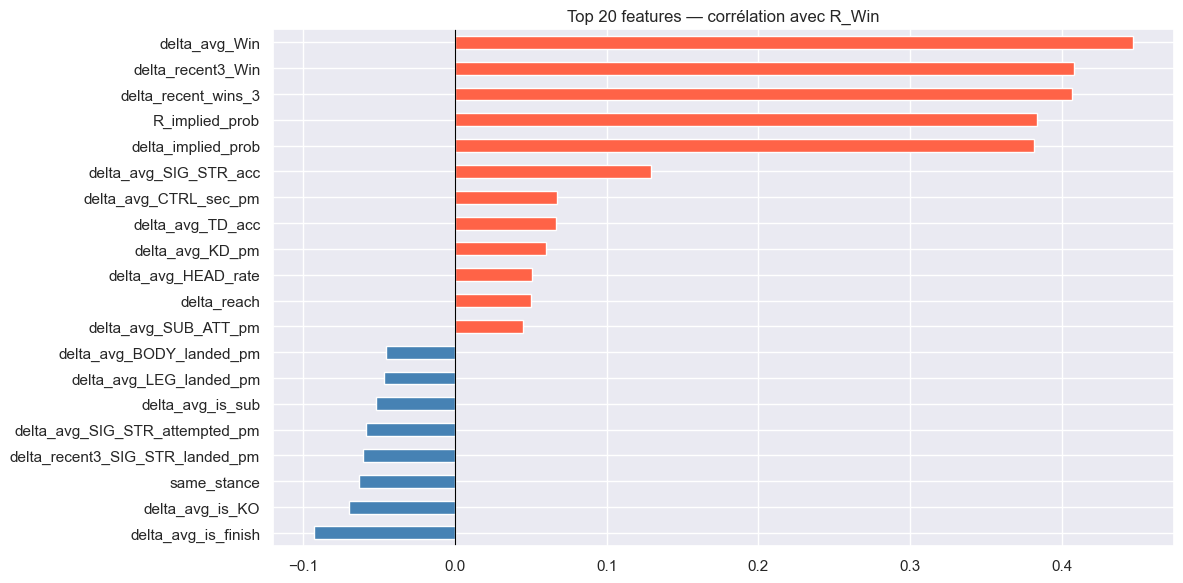

Feature la plus prédictive : delta_avg_Win  (|r| = 0.447)


In [9]:
# Top 20 features par corrélation avec R_Win
num_feats = [c for c in feat_cols if features_df[c].dtype in ['float64', 'float32', 'int64']]
corr = features_df[num_feats + ['R_Win']].corr()['R_Win'].drop('R_Win')
top_corr = corr.abs().sort_values(ascending=False).head(20)
vals = corr[top_corr.index].sort_values()

plt.figure(figsize=(12, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in vals]
vals.plot(kind='barh', color=colors)
plt.title('Top 20 features — corrélation avec R_Win')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
print(f'Feature la plus prédictive : {top_corr.index[0]}  (|r| = {top_corr.iloc[0]:.3f})')

---
## Section 4 — Modèles ML

Split temporel 70/15/15 + Logistic Regression, SVM, Random Forest, XGBoost.

**Règle stricte :** preprocessing (imputation + scaling) fitté uniquement sur le train.

In [20]:
import importlib, src.models.ranking as _rm; importlib.reload(_rm)  # À SUPPRIMER au prochain run complet

from src.models.ranking import (
    temporal_split, make_preprocessor, train_models,
    compare_models, compute_elo, elo_ranking,
    build_fighter_current_stats, rank_by_weights, rank_by_model,
    compare_with_official,
)

train, val, test = temporal_split(features_df)

X_tr  = train[feat_cols].values;  y_tr  = train['R_Win'].values
X_val = val[feat_cols].values;    y_val = val['R_Win'].values
X_te  = test[feat_cols].values;   y_te  = test['R_Win'].values

# Preprocessing (fit UNIQUEMENT sur train)
preproc = make_preprocessor()
X_tr_p  = preproc.fit_transform(X_tr)
X_val_p = preproc.transform(X_val)
X_te_p  = preproc.transform(X_te)

print(f'Train : {len(train):5d} combats  ({train["date"].min().date()} -> {train["date"].max().date()})')
print(f'Val   : {len(val):5d} combats  ({val["date"].min().date()} -> {val["date"].max().date()})')
print(f'Test  : {len(test):5d} combats  ({test["date"].min().date()} -> {test["date"].max().date()})')

Train : 31861 combats  (1994-03-11 -> 2026-02-28)
Val   :  6828 combats  (NaT -> NaT)
Test  :  6828 combats  (NaT -> NaT)


In [11]:
# Baseline : cotes de paris
if 'R_implied_prob' in features_df.columns:
    test_odds = test[test['R_implied_prob'].notna()].copy()
    if len(test_odds) > 10:
        from sklearn.metrics import accuracy_score, roc_auc_score
        pred_odds = (test_odds['R_implied_prob'] > 0.5).astype(int)
        acc = accuracy_score(test_odds['R_Win'], pred_odds)
        auc = roc_auc_score(test_odds['R_Win'], test_odds['R_implied_prob'])
        print(f'Baseline cotes — Accuracy : {acc*100:.1f}%  |  AUC : {auc:.3f}')
        print('Le modele ML doit depasser ces valeurs.')
else:
    print('Pas de cotes disponibles sur ce dataset.')

In [12]:
print('Entrainement des modeles...')
models = train_models(X_tr_p, y_tr, X_val_p, y_val, feat_cols=feat_cols)

Entrainement des modeles...
  [1/4] Logistic Regression...
    LR best params : {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}  |  Val AUC : 0.826
  [2/4] SVM...
    SVM best params : {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}  |  Val AUC : 0.827
  [3/4] Random Forest...
    RF best params : {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 300}  |  Val AUC : 0.822
  [4/4] XGBoost...
[0]	train-auc:0.85241	train-logloss:0.67254	val-auc:0.78191	val-logloss:0.69094
[85]	train-auc:0.93477	train-logloss:0.36190	val-auc:0.80580	val-logloss:0.52612
    XGB best round : 55  |  Val AUC : 0.806


In [13]:
# Tableau de comparaison
results_df, probas = compare_models(models, X_te_p, y_te, X_val_p, y_val, feat_cols=feat_cols)
print('\n=== Comparaison des modeles ===')
print(results_df.to_string(index=False))


=== Comparaison des modeles ===
       Model Val_Acc Val_AUC Test_Acc Test_AUC Test_Brier
      LogReg   73.8%   0.826    63.4%    0.707      0.225
         SVM   75.1%   0.827    63.9%    0.712      0.219
RandomForest   75.3%   0.822    66.7%    0.746      0.205
     XGBoost   73.3%   0.806    63.3%    0.722      0.213


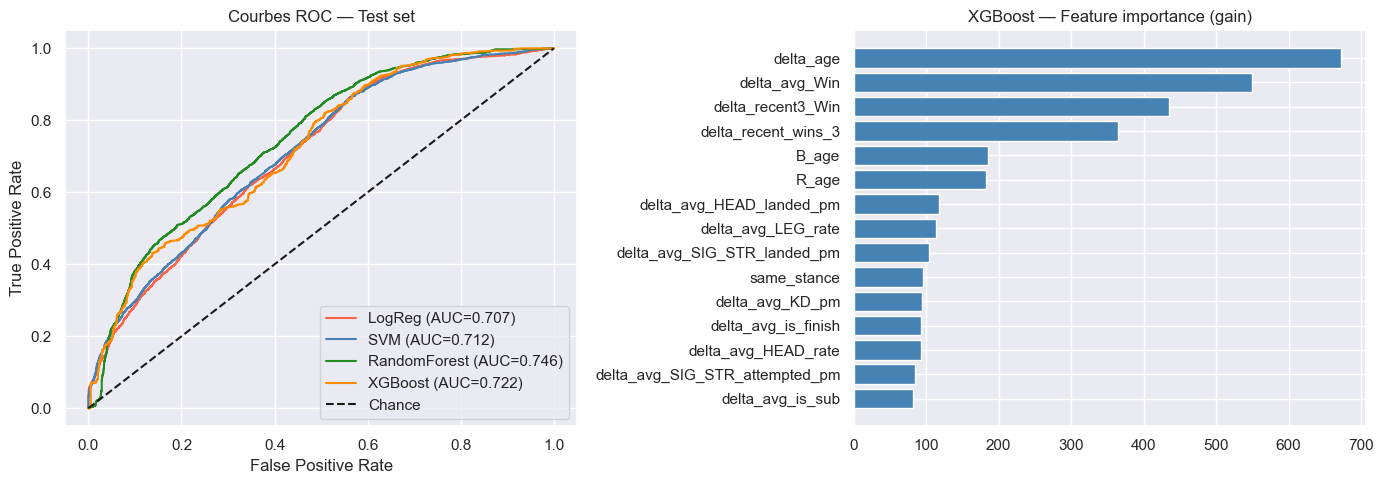

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbes ROC
colors = ['tomato', 'steelblue', 'forestgreen', 'darkorange']
for (name, proba), col in zip(probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc = roc_auc_score(y_te, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=col)
axes[0].plot([0, 1], [0, 1], 'k--', label='Chance')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Courbes ROC — Test set')
axes[0].legend()

# Feature importance XGBoost
if 'XGBoost' in models and isinstance(models['XGBoost'], dict):
    import xgboost as xgb
    booster = models['XGBoost']['booster']
    imp = booster.get_score(importance_type='gain')
    imp_df = pd.DataFrame(imp.items(), columns=['Feature', 'Importance'])
    imp_df = imp_df.sort_values('Importance', ascending=True).tail(15)
    axes[1].barh(imp_df['Feature'], imp_df['Importance'], color='steelblue')
    axes[1].set_title('XGBoost — Feature importance (gain)')
elif 'RandomForest' in models:
    rf = models['RandomForest']
    imp_df = pd.DataFrame({'Feature': feat_cols, 'Importance': rf.feature_importances_})
    imp_df = imp_df.sort_values('Importance', ascending=True).tail(15)
    axes[1].barh(imp_df['Feature'], imp_df['Importance'], color='steelblue')
    axes[1].set_title('Random Forest — Feature importance')

plt.tight_layout()
plt.show()

---
## Section 5 — Classement UFC

Trois méthodes de ranking :
1. **Classement pondéré** — basé sur les poids définis en Section 0
2. **Classement ML round-robin** — `P(A bat B)` pour toutes les paires
3. **Elo dynamique** — historique du niveau de chaque fighter

Comparaison finale avec les classements officiels UFC (Spearman/Kendall).

In [21]:
# Profil actuel de chaque fighter
fighter_stats = build_fighter_current_stats(df)
print(f'Fighters avec stats : {len(fighter_stats)}')
print(f'Fighters avec >= {MIN_FIGHTS_RANKING} combats : {(fighter_stats["n_fights"] >= MIN_FIGHTS_RANKING).sum()}')

Fighters avec stats : 2682
Fighters avec >= 5 combats : 1250


In [22]:
# ─── 1. Classement pondéré ─────────────────────────────────────────────
print('=== CLASSEMENT PONDERE ===')
if WEIGHT_CLASS_FILTER:
    print(f'Division : {WEIGHT_CLASS_FILTER}')
    w_rank = rank_by_weights(fighter_stats, WEIGHTS, WEIGHT_CLASS_FILTER, MIN_FIGHTS_RANKING)
    print(w_rank.head(15).to_string(index=False))
else:
    divisions = ['Heavyweight', 'Light Heavyweight', 'Middleweight', 'Welterweight',
                 'Lightweight', 'Featherweight', 'Bantamweight', 'Flyweight']
    divisions = [d for d in divisions if d in fighter_stats.get('WeightClass', pd.Series()).values]
    if not divisions:
        # Toutes divisions confondues
        w_rank = rank_by_weights(fighter_stats, WEIGHTS, None, MIN_FIGHTS_RANKING)
        print('Top 20 global :')
        print(w_rank.head(20).to_string(index=False))
    else:
        for div in divisions[:4]:  # Afficher les 4 premières
            w_rank = rank_by_weights(fighter_stats, WEIGHTS, div, MIN_FIGHTS_RANKING)
            if len(w_rank) > 0:
                print(f'\n{div.upper()} (Top 10) :')
                print(w_rank.head(10).to_string(index=False))

=== CLASSEMENT PONDERE ===

HEAVYWEIGHT (Top 10) :
 Rank                Fighter  Score  n_fights       WeightClass
    1        Jailton Almeida 0.5501        11       Heavyweight
    2          Carlos Ulberg 0.4809        10 Light Heavyweight
    3           Tom Aspinall 0.4796        10       Heavyweight
    4              Jon Jones 0.4598        24       Heavyweight
    5          Valter Walker 0.4496         5       Heavyweight
    6       Alexandr Romanov 0.4420        10       Heavyweight
    7         Serghei Spivac 0.4198        15       Heavyweight
    8         Curtis Blaydes 0.3998        20       Heavyweight
    9          Nikita Krylov 0.3873        21 Light Heavyweight
   10 Marcos Rogerio de Lima 0.3732        18       Heavyweight

LIGHT HEAVYWEIGHT (Top 10) :
 Rank         Fighter  Score  n_fights       WeightClass
    1   Carlos Ulberg 0.5107        10 Light Heavyweight
    2   Nikita Krylov 0.4982        21 Light Heavyweight
    3 Glover Teixeira 0.4711        23 Light

In [23]:
# ─── 2. Classement ML round-robin ──────────────────────────────────────
# Utiliser le meilleur modèle (sans cotes pour indépendance du marché)
print('=== CLASSEMENT ML (ROUND-ROBIN) ===')

# Preprocessing sans cotes
X_tr_no = train[feat_cols_no_odds].values
X_val_no = val[feat_cols_no_odds].values

preproc_no = make_preprocessor()
X_tr_no_p = preproc_no.fit_transform(X_tr_no)

# Utiliser Logistic Regression (plus rapide pour le round-robin)
best_model_name = results_df.sort_values('Test_AUC', ascending=False).iloc[0]['Model']
print(f'Meilleur modele : {best_model_name}')

# Pour le round-robin, utiliser LR sans cotes
from sklearn.linear_model import LogisticRegression
lr_no = LogisticRegression(max_iter=1000, C=1, solver='liblinear', random_state=42)
lr_no.fit(X_tr_no_p, y_tr)

if WEIGHT_CLASS_FILTER:
    ml_rank = rank_by_model(fighter_stats, lr_no, preproc_no, feat_cols_no_odds,
                             WEIGHT_CLASS_FILTER, MIN_FIGHTS_RANKING)
    print(f'Division : {WEIGHT_CLASS_FILTER}')
    print(ml_rank.head(15).to_string(index=False))
else:
    for div in (['Lightweight', 'Heavyweight', 'Middleweight', 'Welterweight'][:3]):
        ml_rank = rank_by_model(fighter_stats, lr_no, preproc_no, feat_cols_no_odds,
                                 div, MIN_FIGHTS_RANKING)
        if len(ml_rank) > 0:
            print(f'\n{div.upper()} (Top 10) :')
            print(ml_rank.head(10).to_string(index=False))

=== CLASSEMENT ML (ROUND-ROBIN) ===
Meilleur modele : RandomForest

LIGHTWEIGHT (Top 10) :
 Rank            Fighter  Score WeightClass
    1       Chris Duncan  81.40 Lightweight
    2         Fares Ziam  77.10 Lightweight
    3    Islam Makhachev  71.79 Lightweight
    4 Benoit Saint Denis  71.21 Lightweight
    5       Elves Brener  69.34 Lightweight
    6    Claudio Puelles  68.82 Lightweight
    7    Arman Tsarukyan  66.86 Lightweight
    8     Mateusz Gamrot  66.47 Lightweight
    9       Grant Dawson  65.88 Lightweight
   10     Nazim Sadykhov  62.56 Lightweight

HEAVYWEIGHT (Top 10) :
 Rank           Fighter  Score       WeightClass
    1 Azamat Murzakanov  90.75 Light Heavyweight
    2     Valter Walker  82.61       Heavyweight
    3      Alex Pereira  80.74 Light Heavyweight
    4     Vitor Petrino  79.54 Light Heavyweight
    5  Alexandr Romanov  79.45       Heavyweight
    6  Alonzo Menifield  79.07 Light Heavyweight
    7     Bogdan Guskov  78.88 Light Heavyweight
    8    

In [24]:
# ─── 3. Elo dynamique ───────────────────────────────────────────────────
print('=== ELO DYNAMIQUE ===')
elo_final, elo_history = compute_elo(df)

if WEIGHT_CLASS_FILTER:
    elo_rank = elo_ranking(elo_final, WEIGHT_CLASS_FILTER, elo_history)
    print(f'Division : {WEIGHT_CLASS_FILTER}')
    print(elo_rank.head(15).to_string(index=False))
else:
    elo_rank_global = elo_ranking(elo_final)
    print('Top 20 Elo global :')
    print(elo_rank_global.head(20).to_string(index=False))

=== ELO DYNAMIQUE ===
Top 20 Elo global :
 Rank            Fighter    Elo
    1    Islam Makhachev 1699.2
    2      Carlos Ulberg 1685.5
    3      Drakkar Klose 1681.4
    4       Manon Fiorot 1680.4
    5      Natalia Silva 1676.0
    6       Steve Garcia 1671.1
    7      Lerone Murphy 1670.7
    8    Muhammad Mokaev 1668.4
    9         Joshua Van 1665.3
   10       Ilia Topuria 1659.8
   11  Jonathan Martinez 1659.6
   12   Erin Blanchfield 1659.0
   13    Arman Tsarukyan 1658.5
   14 Nassourdine Imavov 1658.1
   15  Ian Machado Garry 1657.1
   16  Merab Dvalishvili 1656.4
   17  Anthony Hernandez 1654.7
   18    Michael Morales 1653.9
   19  Dricus Du Plessis 1653.6
   20       Norma Dumont 1652.2


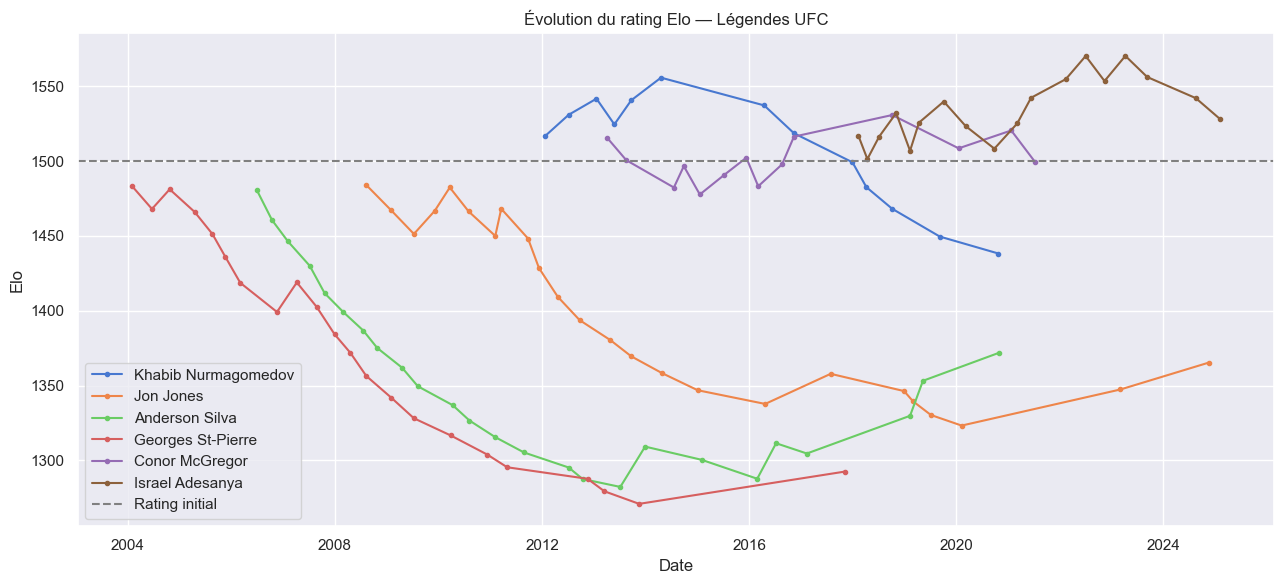

In [25]:
# Évolution Elo des légendes
legends = ['Khabib Nurmagomedov', 'Jon Jones', 'Anderson Silva',
           'Georges St-Pierre', 'Conor McGregor', 'Israel Adesanya']
legends_in_data = [f for f in legends if f in elo_history['Fighter'].values]

if legends_in_data:
    plt.figure(figsize=(13, 6))
    for fighter in legends_in_data:
        fh = elo_history[elo_history['Fighter'] == fighter].sort_values('date')
        plt.plot(fh['date'], fh['Elo'], marker='o', markersize=3, label=fighter)
    plt.axhline(1500, linestyle='--', color='gray', label='Rating initial')
    plt.title('Évolution du rating Elo — Légendes UFC')
    plt.xlabel('Date')
    plt.ylabel('Elo')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Fighters legendes non trouvés dans le dataset.')

In [26]:
# ─── 4. Comparaison avec les classements officiels UFC ──────────────────
print('=== COMPARAISON VS CLASSEMENTS OFFICIELS UFC ===')

# Elo ranking global — comparaison
elo_rank_df = elo_ranking(elo_final)
result = compare_with_official(elo_rank_df, df)

if 'error' in result:
    print(f'Erreur : {result["error"]}')
elif 'message' in result:
    print(result['message'])
else:
    print(f'Fighters comparables : {result["n_fighters"]}')
    print(f'Spearman rho  : {result["spearman_rho"]}  (p={result["p_spearman"]})')
    print(f'Kendall tau   : {result["kendall_tau"]}  (p={result["p_kendall"]})')
    print()
    if result['spearman_rho'] > 0:
        print('Corrélation positive avec le classement officiel UFC.')
    else:
        print('Pas de corrélation significative avec le classement officiel.')
    if 'fighters' in result and len(result['fighters']) > 0:
        print('\nDétail des fighters comparés :')
        print(result['fighters'].to_string(index=False))

=== COMPARAISON VS CLASSEMENTS OFFICIELS UFC ===
Fighters comparables : 209
Spearman rho  : 0.032  (p=0.6488)
Kendall tau   : 0.019  (p=0.6825)

Corrélation positive avec le classement officiel UFC.

Détail des fighters comparés :
                Fighter  official_rank  Rank
            Ailin Perez      15.000000    70
        Aleksei Oleinik      15.000000  2508
           Alex Caceres      15.000000  2519
           Alex Pereira       0.000000    23
             Alex Perez       6.000000   701
           Alexa Grasso       1.666667   147
  Alexander Volkanovski       0.000000   219
       Alexander Volkov       6.500000   143
       Alexandr Romanov      13.500000   576
      Alexandre Pantoja       1.400000    99
      Aljamain Sterling       0.000000   366
       Alonzo Menifield      12.500000    52
           Amanda Lemos       6.750000   134
           Amanda Nunes       0.000000  2318
           Amanda Ribas       9.000000  1345
            Amir Albazi       9.500000  1339
    

---
## Fin du pipeline

Pour relancer le pipeline sur de nouvelles données, exécutez à nouveau ce notebook. Seuls les combats postérieurs au dernier run seront scrapés et intégrés.

Pour modifier les poids du classement, éditez le dict `WEIGHTS` en Section 0.